In [1]:
# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '../')


In [2]:
# Runge-Kutta 4th order method for ODE solving
def rk4_step_func(func, x0, dt, u):
    k1 = func(x0, u)
    k1 = k1*dt

    k2 = func(x0+k1/2, u)
    k2 = k2*dt

    k3 = func(x0+k2/2, u)
    k3 = k3*dt

    k4 = func(x0+k3, u)
    k4 = k4*dt

    return x0 + (k1 + 2 * (k2 + k3) + k4) / 6

In [3]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F
n_neurons = 32
dropout_rate = 0.1
class MotorModel(nn.Module):
    def __init__(self, u_size=1, x_size=3):  
        super(MotorModel, self).__init__()
        # Fully connected layers
        self.A1 = nn.Linear(x_size, n_neurons) 
        self.A2 = nn.Linear(n_neurons, n_neurons)
        self.A3 = nn.Linear(n_neurons, n_neurons)
        self.A4 = nn.Linear(n_neurons, n_neurons)
        self.outputA = nn.Linear(n_neurons, x_size)

        self.B1 = nn.Linear(u_size, n_neurons) 
        self.B2 = nn.Linear(n_neurons, n_neurons)
        self.outputB = nn.Linear(n_neurons, x_size)
        
        self.dropout = nn.Dropout(dropout_rate)
        

    def forward(self, x0, u):
        
        outA = F.softplus(self.A1(x0))
        outA = self.dropout(F.softplus(self.A2(outA)))
        outA = self.dropout(F.softplus(self.A3(outA)))
        outA = self.dropout(F.softplus(self.A4(outA)))
        outA = self.outputA(outA)

        outB = F.softplus(self.B1(u))
        outB = self.dropout(F.softplus(self.B2(outB)))
        outB = self.outputB(outB)

        x = outA + outB  
        return x

# Create the model
model = MotorModel()

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

MotorModel(
  (A1): Linear(in_features=3, out_features=32, bias=True)
  (A2): Linear(in_features=32, out_features=32, bias=True)
  (A3): Linear(in_features=32, out_features=32, bias=True)
  (A4): Linear(in_features=32, out_features=32, bias=True)
  (outputA): Linear(in_features=32, out_features=3, bias=True)
  (B1): Linear(in_features=1, out_features=32, bias=True)
  (B2): Linear(in_features=32, out_features=32, bias=True)
  (outputB): Linear(in_features=32, out_features=3, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 4614


In [4]:
model = MotorModel()
dt = 1e-3
loaded_state_dict = torch.load("node_ABmats_v2.pth")
model.load_state_dict(loaded_state_dict)


<All keys matched successfully>

In [5]:
# One step evaluation
import torch.optim as optim
from torcheval.metrics.functional import mean_squared_error, r2_score

def one_step_eval_rk4(model, x,u,dt):
    t = 0
    predictions = torch.zeros_like(x)
    model.eval()
    xk = x[0]
    torch.no_grad()
    for i in range(x.shape[0]-1):

        pred = rk4_step_func(model, xk, dt, u[i].unsqueeze(-1) )  # Integrate over a small time step
        predictions[i+1] = pred
        xk = pred
        # Backward and optimize
    r2 = r2_score(predictions[1:], x[1:])
    raw_r2 = r2_score(predictions[1:], x[1:], multioutput='raw_values')
    mse = mean_squared_error(predictions[1:], x[1:])
    return predictions, mse, r2, raw_r2

In [6]:
import nn_fncs
mat_data = nn_fncs.read_mat_workspace('../Data/motor1_diff_delta_r.mat')
motor_p = mat_data.get('motor_pout1')
u_signals = motor_p[:,0]
x_motor = mat_data.get('xoutmotor1')

print(f'u_signals shape: {u_signals.shape}')  # (num_trajectories, num_time_steps, num_motors)
print(f'x_motor shape: {x_motor.shape}')      # (num_trajectories

u_signals shape: (1500,)
x_motor shape: (1500, 3)


In [7]:
# Load scalers
import joblib
scaler_u = joblib.load('../Scalers/u_scaler.pkl')
scaler_x = joblib.load('../Scalers/x_scaler.pkl')

# Scale data

# x_motor = scaler_x.transform(x_motor)
# u_signals = scaler_u.transform(u_signals.reshape(-1, 1)).flatten()

In [12]:
# Choose a random test trajectory
from random import randint  
test_size = 15000
model1 = MotorModel()
dt = 1e-3
loaded_state_dict = torch.load("node_ABmats_v2_1.pth")
model1.load_state_dict(loaded_state_dict)

model2 = MotorModel()
loaded_state_dict = torch.load("node_ABmats_v2_2.pth")
model2.load_state_dict(loaded_state_dict)

model3 = MotorModel()
loaded_state_dict = torch.load("node_ABmats_v2.pth")
model3.load_state_dict(loaded_state_dict)

id = randint(0,u_signals.shape[0]-1)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model1 = model1.to(device)
model2 = model2.to(device)
model3 = model3.to(device)

pred1, mse, r2, raw_r2 = one_step_eval_rk4(model1, torch.tensor(x_motor[:test_size], dtype=torch.float32).to(device),
                                torch.tensor(u_signals[:test_size], dtype=torch.float32).to(device).unsqueeze(-1),dt=dt)
print(f'Loss: {mse.item()}, R2: {r2.item()}, Raw R2: {raw_r2}')

pred2, mse, r2, raw_r2 = one_step_eval_rk4(model2, torch.tensor(x_motor[:test_size], dtype=torch.float32).to(device),
                                torch.tensor(u_signals[:test_size], dtype=torch.float32).to(device).unsqueeze(-1),dt=dt)
print(f'Loss: {mse.item()}, R2: {r2.item()}, Raw R2: {raw_r2}')

pred3, mse, r2, raw_r2 = one_step_eval_rk4(model3, torch.tensor(x_motor[:test_size], dtype=torch.float32).to(device),
                                torch.tensor(u_signals[:test_size], dtype=torch.float32).to(device).unsqueeze(-1),dt=dt)
print(f'Loss: {mse.item()}, R2: {r2.item()}, Raw R2: {raw_r2}')

Loss: 4.8759846687316895, R2: -6.7205400466918945, Raw R2: tensor([ -0.1394,  -5.6224, -14.3998], device='cuda:0')
Loss: 5.940244674682617, R2: -6.306708335876465, Raw R2: tensor([  0.0854,   0.0553, -19.0608], device='cuda:0')
Loss: 1.566063642501831, R2: -0.7251335978507996, Raw R2: tensor([ 0.2396,  0.6254, -3.0404], device='cuda:0')


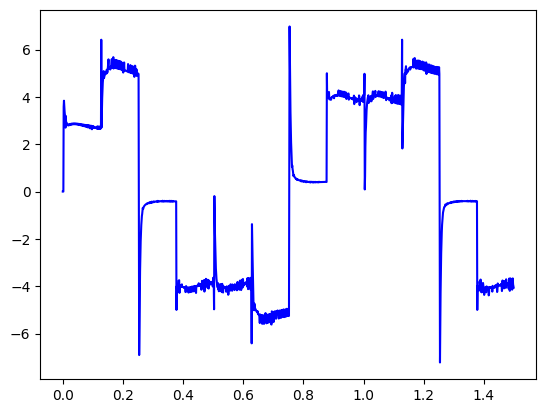

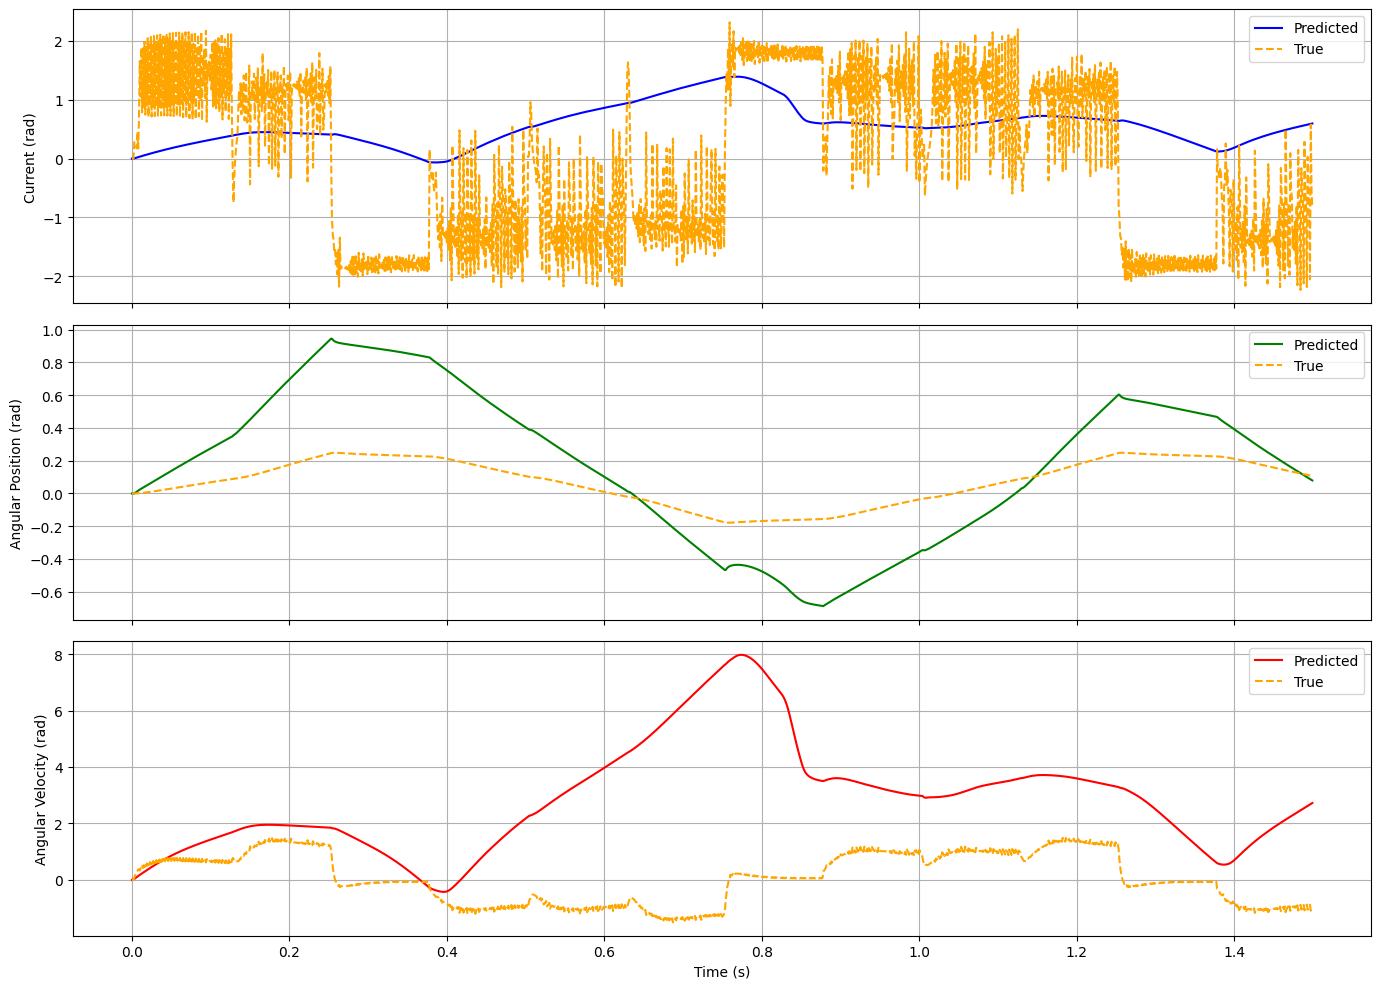

In [13]:
import matplotlib.pyplot as plt

# Prepare time axis
time = torch.arange(0, pred1.shape[0]*dt, dt)
#Plot u signals
plt.plot(time.cpu(), u_signals[:], label='Current', color='blue')
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
labels = ['Current', 'Angular Position', 'Angular Velocity']
colors = ['blue', 'green', 'red']

for i in range(3):
    axs[i].plot(time.cpu(), pred1[:, i].cpu().detach().numpy(), label='Predicted', color=colors[i])
    axs[i].plot(time.cpu(), x_motor[:, i], label='True', color='orange', linestyle='--')
    axs[i].set_ylabel(f'{labels[i]} (rad)')
    axs[i].legend()
    axs[i].grid(True)

axs[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

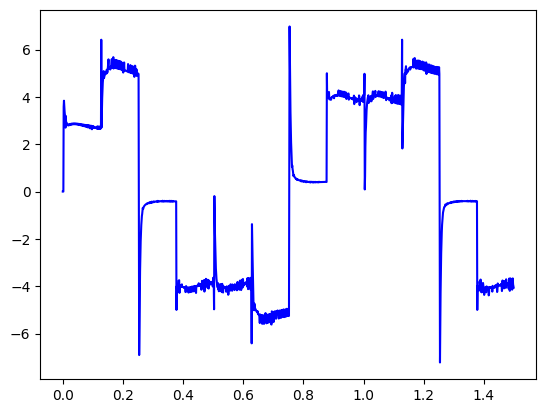

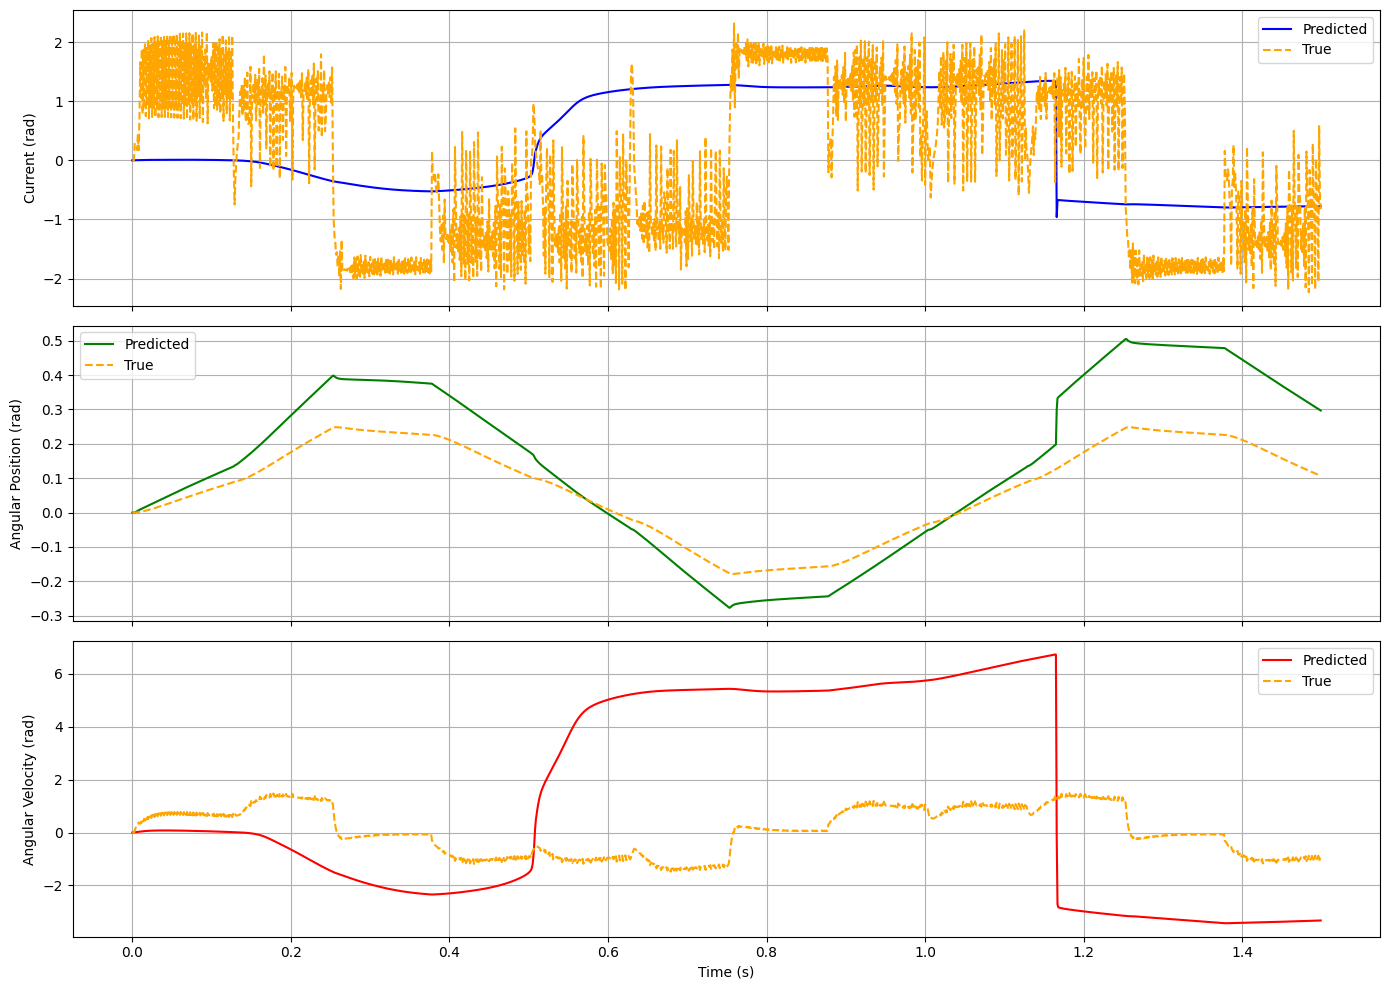

In [14]:
import matplotlib.pyplot as plt

# Prepare time axis
time = torch.arange(0, pred2.shape[0]*dt, dt)
#Plot u signals
plt.plot(time.cpu(), u_signals[:], label='Current', color='blue')
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
labels = ['Current', 'Angular Position', 'Angular Velocity']
colors = ['blue', 'green', 'red']

for i in range(3):
    axs[i].plot(time.cpu(), pred2[:, i].cpu().detach().numpy(), label='Predicted', color=colors[i])
    axs[i].plot(time.cpu(), x_motor[:, i], label='True', color='orange', linestyle='--')
    axs[i].set_ylabel(f'{labels[i]} (rad)')
    axs[i].legend()
    axs[i].grid(True)

axs[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

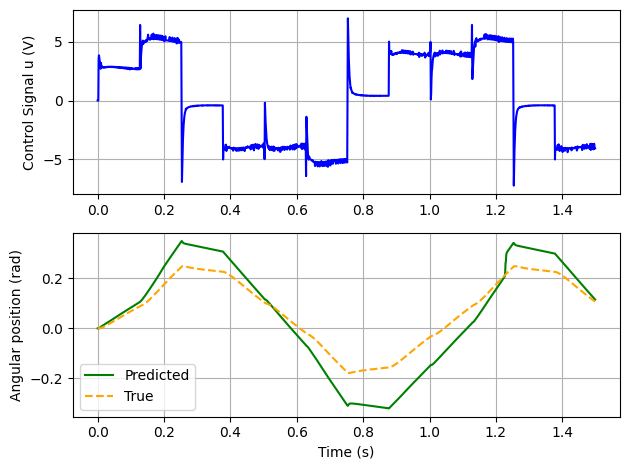

In [15]:
import matplotlib.pyplot as plt

# Prepare time axis
time = torch.arange(0, pred3.shape[0]*dt, dt)
#Plot u signals
plt.subplot(2, 1, 1)
plt.plot(time.cpu(), u_signals[:], label='Current', color='blue')
plt.ylabel(f'Control Signal u (V)')
plt.grid(True)
plt.subplot(2,1,2)

plt.plot(time.cpu(), pred3[:, 1].cpu().detach().numpy(), label='Predicted', color='green')
plt.plot(time.cpu(), x_motor[:, 1], label='True', color='orange', linestyle='--')
plt.ylabel(f'Angular position (rad)')
plt.legend()
plt.grid(True)

plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()  